# Top

In [ ]:
%matplotlib inline
%load_ext autoreload
import sys

sys.path.append("../")
sys.path.append("/app")

from verimon.analysis import *

experiment_dir = (
    "../out/exp-2025-11-28_17-09-36-bisection/"
)
experiment_data = load_experiment_data(experiment_dir)

add_learning_rounds(experiment_data)

experiment_data = combine_sampling_and_verimon(
    experiment_data,
    [
        "file",
        "parameters",
        "horizon",
        "use_random_eq",
        "verimon_walks_per_state",
        "old_walks_per_state",
    ],
)
symbols, colors = add_symbol_color(experiment_data)

clean_data(experiment_data)

add_short_names(experiment_data)

experiments_in_legends = True
save_figures = False
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"
verimon_data = [d for d in experiment_data if "verimon" in d]

plot_kwargs = {
    "fillstyle": "none",
    "markeredgewidth": 1,
    "markersize": 4,
}

Loaded 60/4/0 (93.75%) JSON files from ../out/exp-2025-11-28_17-09-36-bisection/


In [2]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*quotient: \([0-9]\+\) states.*/\1/' | awk '{sum+=$1; n+=1; if(min==""){min=$1}; if($1>max){max=$1}; if($1<min){min=$1}} END{printf "min=%d, avg=%.2f, max=%d\n", min, sum/n, max}'"""
)
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*family size: \([0-9e+]\+\).*/\1/' | awk '{val=$1+0; sum+=val; c++; if(NR==1){min=val; max=val} else {if(val>max){max=val}; if(val<min){min=val}}} END{printf "min=%.0f, avg=%.2f, max=%.0f\n", min, sum/c, max}'"""
)
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h)): {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']}."
)

../out/exp-2025-11-28_17-09-36-bisection//logs/2025-11-28_17-09-36_airport_(file=airportA-3.nm,parameters={'constants': 'DMAX=5,PMAX=5'},horizon=11,use_exact=False,conditional_method=rejection).log:WARNING:2025-11-29 04:54:18,678 - (0.00s) - verify.py:290 - paynt value and checking value differ: 0.49999999931747496 vs goal:0.24722691298271932 or stop:0.7527730660270497
../out/exp-2025-11-28_17-09-36-bisection//logs/2025-11-28_17-09-36_airport_(file=airportA-3.nm,parameters={'constants': 'DMAX=5,PMAX=5'},horizon=11,use_exact=False,conditional_method=rejection).log:WARNING:2025-11-29 04:54:18,679 - (0.00s) - verify.py:312 - Paynt value and filtering value differ: 0.49999999931747496 vs 0.2472269194756554
../out/exp-2025-11-28_17-09-36-bisection//logs/2025-11-28_17-09-36_refuel_(file=refuel.nm,parameters={'constants': 'N=3,ENERGY=3'},use_exact=False,conditional_method=rejection).log:WARNING:2025-11-28 17:21:13,033 - (0.00s) - verify.py:290 - paynt value and checking value differ: 0.499999

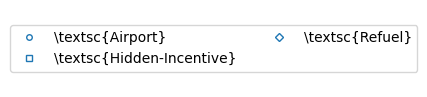

In [3]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

name_map = {
    "airport": r"\textsc{Airport}",
    "evade": r"\textsc{Evade}",
    "refuel": r"\textsc{Refuel}",
    "icy-driving": r"\textsc{Icy-Driving}",
    "hidden_incentive": r"\textsc{Hidden-Incentive}",
    "snakes_ladders": r"\textsc{SnL}",
}
legend_elements = {}
for data in verimon_data:
    if data["experiment"]["name"] not in legend_elements:
        legend_elements[data["experiment"]["name"]] = mlines.Line2D(
            [],
            [],
            linewidth=0,
            color=data["color"],
            marker=data["symbol"],
            **plot_kwargs,
            label=f"{name_map[data['experiment']['name']]}",
        )

# Create a legend for the symbols and colors
# legend_elements = [
#     mlines.Line2D(
#         [],
#         [],
#         linewidth=0,
#         color=data["color"],
#         marker=data["symbol"],
#         label=f"({data['experiment']['short_name']}) {data['experiment']['name']} {data['experiment']['variant']}",
#     )
#     for data in verimon_data
# ]

plt.legend(handles=legend_elements.values(), loc="center", ncol=2)
plt.axis("off")
plt.gcf().set_size_inches(2, 1)
if save_figures:
    plt.savefig(f"{save_path}/legend.pgf", bbox_inches="tight")
plt.show()

# generate_learn_table(verimon_data, True, save_path, "experiments")

# Correctness of monitors

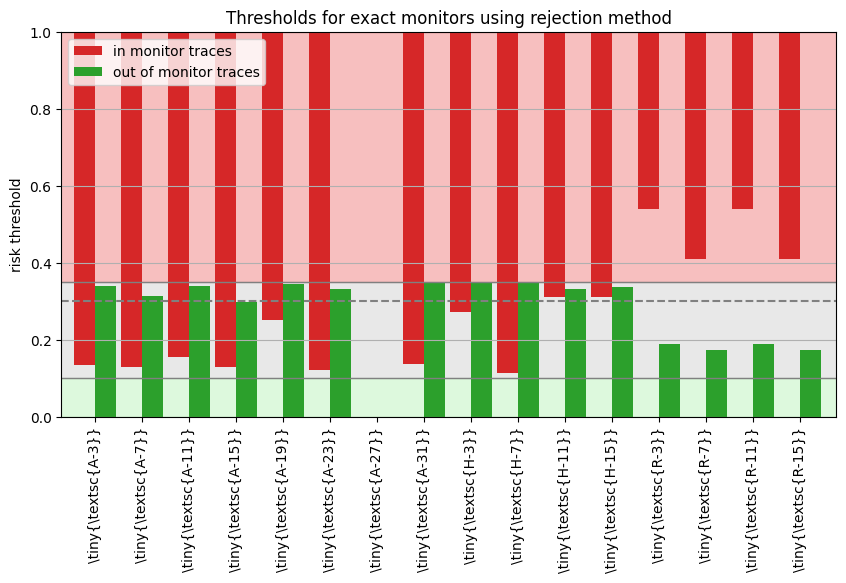

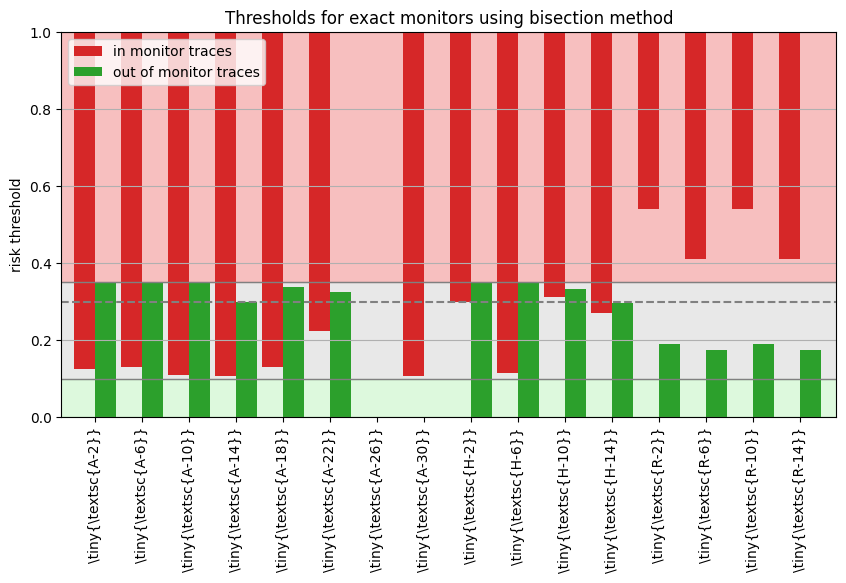

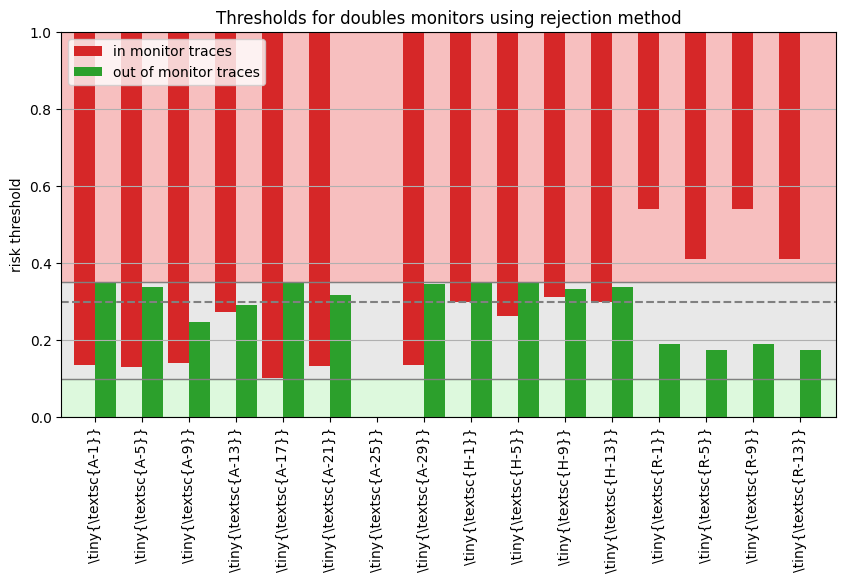

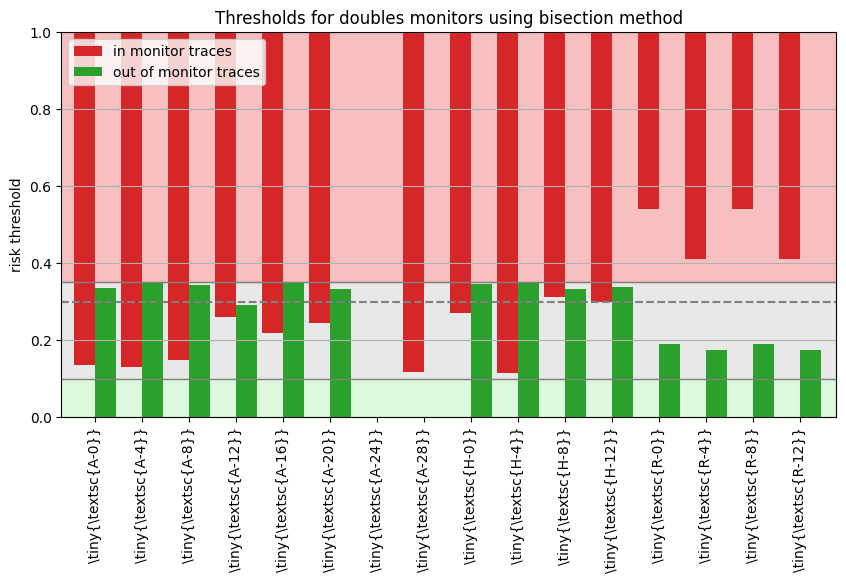

In [4]:
for exact in [True, False]:
    for conditional_method in ["rejection", "bisection"]:
        compare_thresholds_bar(
            [
                d
                for d in experiment_data
                if d["experiment"]["use_exact"] == exact
                and d["experiment"]["conditional_method"] == conditional_method
            ],
            ["verimon"],
            "name",
            lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
            0.3,
            0.05,
            0.2,
            # fig_size=(6, 2),
            fig_size=(10, 5),
            experiments_in_legends=experiments_in_legends,
            save_figures=save_figures,
            save_path=save_path,
            title=f"Thresholds for {'exact' if exact else 'doubles'} monitors using {conditional_method} method",
            file_name=f"thresholds_tover_{'exact' if exact else 'doubles'}_{conditional_method}",
            show_y_axis=True,
        )

# Runtime Comparison

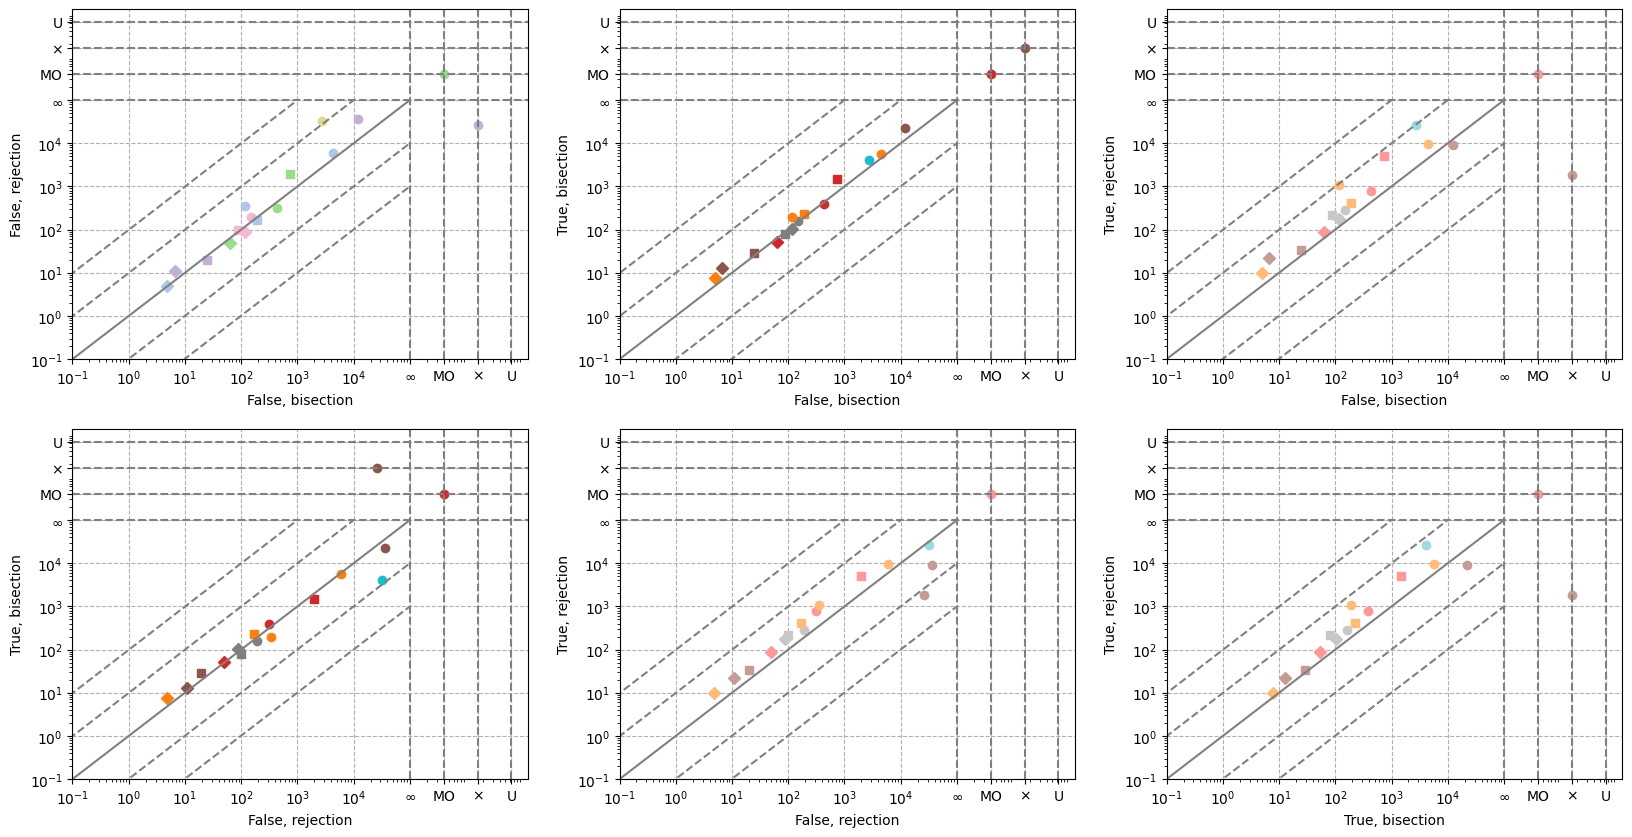

In [5]:
parameters = ["use_exact", "conditional_method"]
compare_runtime_by_params(
    experiment_data,
    parameters,
)

# Runtime by parameters

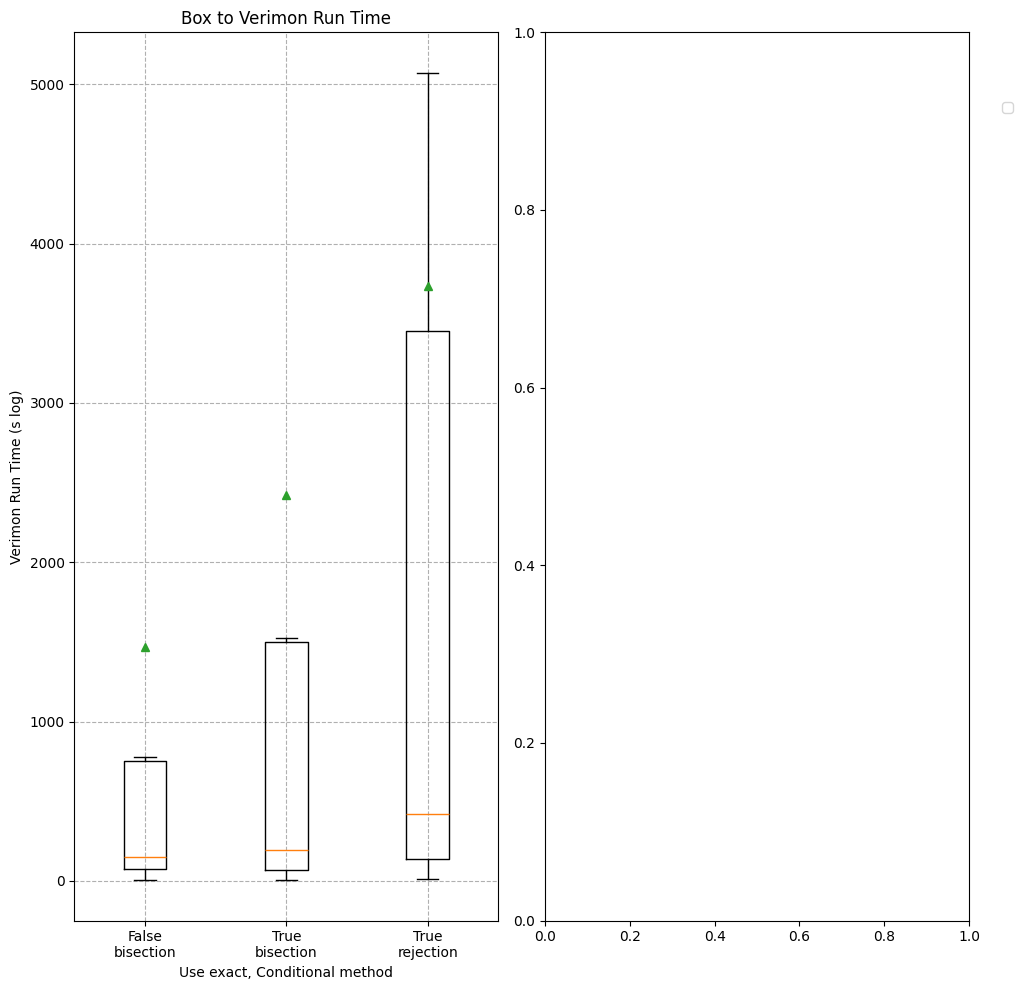

In [6]:
parameters = [
    # (("experiment", "conditional_method"), "box"),
    # (("experiment", "use_exact"), "box"),
    ([("experiment", "use_exact"), ("experiment", "conditional_method")], "box"),
]

runtime_by_params(
    [
        data
        for data in experiment_data
        if not (
            data["experiment"]["use_exact"] == False
            and data["experiment"]["conditional_method"] == "rejection"
        )
    ],
    "verimon",
    parameters,
    experiments_in_legends=experiments_in_legends,
    plot_kwargs=plot_kwargs,
    fit_line=False,
)

# Relative time spent in paynt, product generator and other

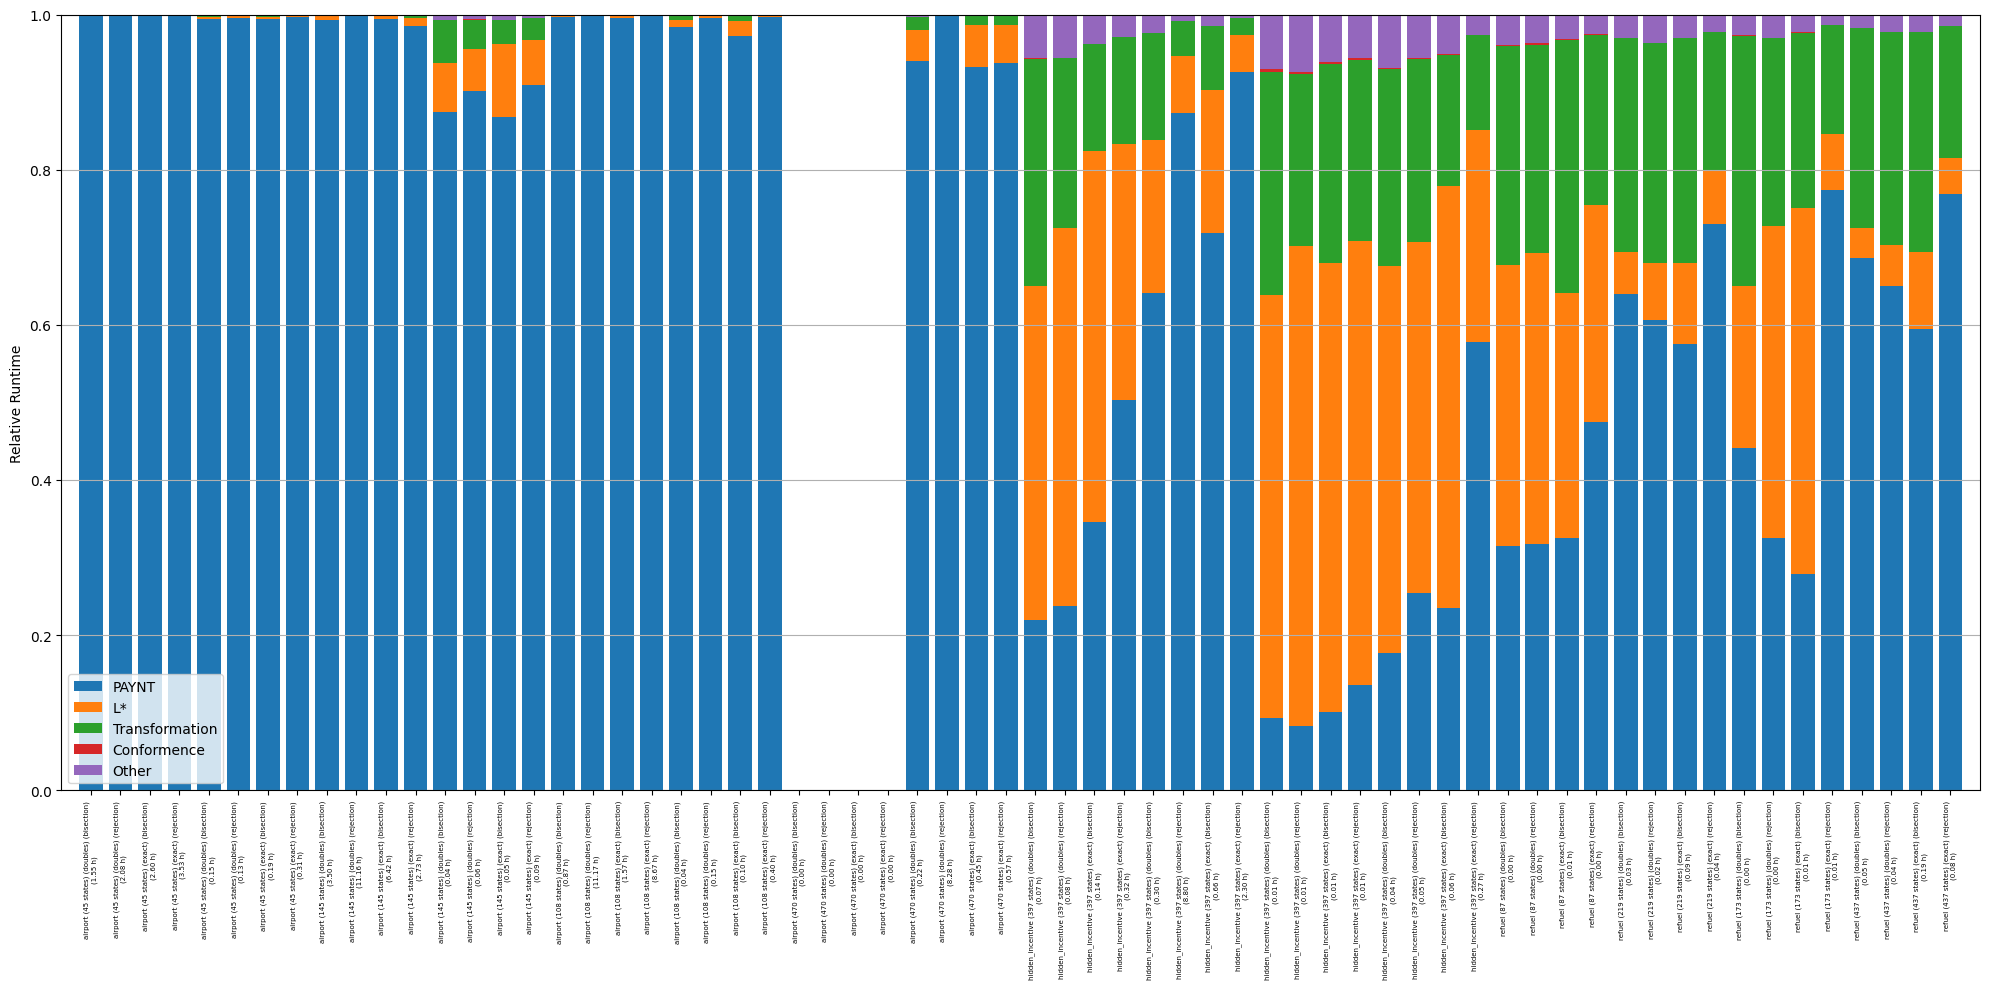

In [7]:
import numpy as np


filtered_data = [
    data for data in experiment_data if data["experiment"]["name"] != "compare-trad"
]
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
eq_times = [
    (
        data["verimon"]["eq_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
lstar_times = [
    (
        data["verimon"]["lstar_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
other_times = [
    (
        1
        - (
            data["verimon"]["product_time"]
            + data["verimon"]["paynt_time"]
            + data["verimon"]["eq_time"]
            + data["verimon"]["lstar_time"]
        )
        / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]

if experiments_in_legends:
    experiment_names = [
        f"{data['experiment']['name']} ({data['mc']['mc_states']} states) "
        f"({'exact' if data['experiment']['use_exact'] else 'doubles'}) ({data['experiment']['conditional_method']})"
        f"\n({data['time']['total'] / (60 * 60):.2f} h)"
        for data in filtered_data
    ]
else:
    experiment_names = [
        f"({data['time']['total'] / (60 * 60):.2f} h) {data['experiment']['short_name']}"
        for data in filtered_data
    ]

plt.figure(figsize=(7, 3))
index = range(len(filtered_data))
bottom = np.zeros(len(filtered_data))


plt.bar(index, paynt_times, width=0.8, label="PAYNT")
bottom += paynt_times
plt.bar(index, lstar_times, bottom=bottom, width=0.8, label="L*")
bottom += lstar_times
plt.bar(index, product_times, bottom=bottom, width=0.8, label="Transformation")
bottom += product_times
plt.bar(
    index,
    eq_times,
    bottom=bottom,
    width=0.8,
    label="Conformence",
)
bottom += eq_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    width=0.8,
    label="Other",
)

plt.ylabel("Relative Runtime")
plt.xticks(index, experiment_names, rotation=90, fontsize=5)
plt.legend(loc="lower left")
plt.xlim(-1, len(filtered_data))
plt.ylim(0, 1)

fig = plt.gcf()
fig.set_size_inches(20, 10)

plt.tight_layout()
plt.grid(axis="y")
if save_figures:
    plt.savefig(f"{save_path}/verimon_times.pgf", bbox_inches="tight")
plt.show()

In [8]:
from verimon.analysis import runtime_from_logs

sorted_experiment_data = sorted(
    experiment_data, key=lambda d: d["time"]["total"], reverse=True
)
for data in experiment_data:
    if "verimon" in data:
        print(
            "\n",
            data["experiment"]["name"],
            data["experiment"]["variant"],
            data["time"]["total"],
        )
        print(data["log_path"].replace("../", "./"))
        times, example_msg = runtime_from_logs(data["log_path"])
        print(
            "\n".join(
                map(
                    lambda t: f"{t[0]} ({t[1]}): {example_msg[t[0]]}",
                    sorted(times.items(), key=lambda x: x[1], reverse=True)[:5],
                )
            )
        )


 airport (file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},horizon=11,use_exact=False,conditional_method=bisection) 5586.384215831757
./out/exp-2025-11-28_17-09-36-bisection//logs/2025-11-28_17-09-36_airport_(file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},horizon=11,use_exact=False,conditional_method=bisection).log
generator.py:208 (3434.2799999999997): counterexample found: A(3,0)={d:1,pobs:2,turn:0}, A(4,0)={d:1,pobs:2,turn:1}, A(5,0)={d:1,pobs:2,turn:0}, A(6,0)={d:1,pobs:0,turn:0}, A(7,0)={d:1,pobs:0,turn:1}, A(8,0)={d:0,pobs:0,turn:1}, A(9,0)=end, A(10,0)={d:0,pobs:0,turn:0}, A(11,0)=end, A(12,0)={d:0,pobs:0,turn:1}, A(13,0)={d:0,pobs:0,turn:0}, A(14,0)={d:1,pobs:2,turn:0}, A(15,0)=end, A(16,0)={d:1,pobs:0,turn:1}, A(17,0)={d:2,pobs:2,turn:0}, A(18,0)={d:1,pobs:2,turn:0}, A(19,0)=end, A(20,0)={d:1,pobs:0,turn:1}, A(21,0)=end (None)
generator.py:218 (2147.65): no counterexamples above threshold
MonitorLearning.py:280 (2.28): Finding counterexample for hypo